In [1]:
import matplotlib.pyplot as plt
from torch_geometric.nn.models import DimeNetPlusPlus
from torch import nn
from torch_geometric.loader import DataLoader
import torch
from polymer_project_compact.src.visualisation import plot_scatter
from polymer_project_compact.src.prediction import predict_1d_target
from polymer_project_compact.src.training import train
from polymer_project_compact.src.load_data import load_data_files, load_data_list
from sklearn.metrics import mean_absolute_error

# Pretrain

In [2]:
directory_pretrain = r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\data\NREL_opv\NREL_opv_dataset_DFT_geom_to_prop_dimenet_extrapol_filter_1-2.4'

data_pretrain = load_data_files(directory_pretrain, target=1, exclude_atom=1)

In [3]:
params = {
    'hidden_channels': 256,
    'out_channels': 1,
    'num_blocks': 4,
    'max_num_neighbors': 64,
    'int_emb_size': 64,
    'basis_emb_size': 8,
    'out_emb_channels': 256,
    'num_spherical': 4,
    'num_radial': 3,
    'output_initializer': 'zeros',
    'cutoff': 5,
    'envelope_exponent': 5,
    'num_before_skip': 1,
    'num_after_skip': 2,
    'num_output_layers': 4,
    'act': 'swish'
}

model_pretrain = DimeNetPlusPlus(**params).to('cuda')

optimizer = torch.optim.AdamW(model_pretrain.parameters(), lr=0.0008, weight_decay=0.0, amsgrad=True)
loss_function = nn.MSELoss().to('cuda')

In [4]:
from sklearn.preprocessing import QuantileTransformer, RobustScaler, PowerTransformer

train_data_list_pretrain, val_data_list_pretrain, test_data_list_pretrain = load_data_list(train_size=0.8, val_size=0.1, data_list=data_pretrain)

train_y_pretrain = torch.cat([data.y for data in train_data_list_pretrain]).numpy()

transform_function = PowerTransformer(method='box-cox')
# transform_function = RobustScaler()
train_y_pretrain_transformed = transform_function.fit_transform(train_y_pretrain.reshape(-1, 1))

def apply_transform(data_list, transformer):
    for data in data_list:
        y_numpy = data.y.numpy()
        y_transformed = transformer.transform(y_numpy.reshape(-1, 1))
        data.y = torch.tensor(y_transformed, dtype=torch.float32)

apply_transform(train_data_list_pretrain, transform_function)
apply_transform(val_data_list_pretrain, transform_function)
apply_transform(test_data_list_pretrain, transform_function)

train_loader_pretrain = DataLoader(train_data_list_pretrain, batch_size=100, shuffle=True, pin_memory=True, num_workers=0)
val_loader_pretrain = DataLoader(val_data_list_pretrain, batch_size=100, shuffle=False, pin_memory=True, num_workers=0)
test_loader_pretrain = DataLoader(test_data_list_pretrain, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)

## Train cycle

In [ ]:
train(model_pretrain, optimizer, loss_function,
      num_epochs=50,
      train_loader=train_loader_pretrain,
      val_loader=val_loader_pretrain,
      ylim=[0, 0.15],
      save_model=False)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
prediction_pretrain = predict_1d_target(model_pretrain, data_loaders=[train_loader_pretrain, val_loader_pretrain, test_loader_pretrain])

y_train_pred_pretrain, y_train_true_pretrain = prediction_pretrain[0]

y_test_pred_pretrain, y_test_true_pretrain = prediction_pretrain[1]

In [ ]:
y_train_pred_t_pretrain = transform_function.inverse_transform(y_train_pred_pretrain.reshape(-1, 1)).flatten()
y_train_true_t_pretrain = transform_function.inverse_transform(y_train_true_pretrain.reshape(-1, 1)).flatten()

y_test_pred_t_pretrain = transform_function.inverse_transform(y_test_pred_pretrain.reshape(-1, 1)).flatten()
y_test_true_t_pretrain = transform_function.inverse_transform(y_test_true_pretrain.reshape(-1, 1)).flatten()

In [ ]:
plot_scatter(y_train_true_t_pretrain, y_train_pred_t_pretrain,
             axis_lims=[3.5, 6, 3.5, 6],
             s=5,
             graph_title='Тренировочные данные',
             x_label='Расчет TD-DFT, ev')

plot_scatter(y_test_true_t_pretrain, y_test_pred_t_pretrain,
             axis_lims=[3.5, 6, 3.5, 6],
             s=5,
             graph_title='Тестовые данные',
             x_label='Расчет TD-DFT, ev')

In [ ]:
mae_train_pretrain = mean_absolute_error(y_train_true_t_pretrain, y_train_pred_t_pretrain)
mae_test_pretrain = mean_absolute_error(y_test_true_t_pretrain, y_test_pred_t_pretrain)

print(f'MAE Train: {mae_train_pretrain:.4f}')
print(f'MAE Test: {mae_test_pretrain:.4f}')

# Fine-tuning

In [5]:
params = {
    'hidden_channels': 256,
    'out_channels': 1,
    'num_blocks': 4,
    'max_num_neighbors': 64,
    'int_emb_size': 64,
    'basis_emb_size': 8,
    'out_emb_channels': 256,
    'num_spherical': 4,
    'num_radial': 3,
    'output_initializer': 'zeros',
    'cutoff': 3.5,
    'envelope_exponent': 5,
    'num_before_skip': 1,
    'num_after_skip': 2,
    'num_output_layers': 4,
    'act': 'swish'
}

model = DimeNetPlusPlus(**params).to('cuda')
loss_function = nn.MSELoss().to('cuda')

model.load_state_dict(torch.load(r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\models\extrapolation_based\DimeNet_NREL_homo_pretrained_filter_1-2.4_v_1.pt'))

<All keys matched successfully>

In [19]:
torch.cuda.empty_cache()

In [10]:
# model_fine_tune.rbf.freq.requires_grad = False
# model_fine_tune.rbf.freq.requires_grad = False
# model_fine_tune.emb.emb.weight.requires_grad = False
# model_fine_tune.emb.lin_rbf.weight.requires_grad = False
# model_fine_tune.emb.lin_rbf.bias.requires_grad = False
# model_fine_tune.emb.lin.weight.requires_grad = False
# model_fine_tune.emb.lin.bias.requires_grad = False
#
# for i, block in enumerate(model_fine_tune.interaction_blocks):
#     block.lin_rbf1.weight.requires_grad = False
#     block.lin_rbf2.weight.requires_grad = False
#     block.lin_sbf1.weight.requires_grad = False
#     block.lin_sbf2.weight.requires_grad = False
#     block.lin_ji.weight.requires_grad = False
#     block.lin_ji.bias.requires_grad = False
#     block.lin_kj.weight.requires_grad = False
#     block.lin_kj.bias.requires_grad = False
#     block.lin_down.weight.requires_grad = False
#     block.lin_up.weight.requires_grad = False
#
#     for j, layer in enumerate(block.layers_before_skip):
#         layer.lin1.weight.requires_grad = False
#         layer.lin1.bias.requires_grad = False
#         layer.lin2.weight.requires_grad = False
#         layer.lin2.bias.requires_grad = False
#
#     block.lin.weight.requires_grad = False
#     block.lin.bias.requires_grad = False
#
#     for j, layer in enumerate(block.layers_after_skip):
#         layer.lin1.weight.requires_grad = False
#         layer.lin1.bias.requires_grad = False
#         layer.lin2.weight.requires_grad = False
#         layer.lin2.bias.requires_grad = False

In [6]:
directory_fine_tune = r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\data\polymers\poly_v_2_graph_geom_to_prop_Hs_dimenet'

data_fine_tune = load_data_files(directory_fine_tune, target=1, exclude_atom=1)

In [7]:
train_data_list_fine_tune, val_data_list_fine_tune, test_data_list_fine_tune = load_data_list(train_size=0.8, val_size=0.1, data_list=data_fine_tune)

train_y_fine_tune = torch.cat([data.y for data in train_data_list_fine_tune]).numpy()

train_y_fine_tune_transformed = transform_function.transform(train_y_fine_tune.reshape(-1, 1))

apply_transform(train_data_list_fine_tune, transform_function)
apply_transform(val_data_list_fine_tune, transform_function)
apply_transform(test_data_list_fine_tune, transform_function)

# train_loader_fine_tune = DataLoader(train_data_list_fine_tune, batch_size=150, shuffle=True, pin_memory=False, num_workers=0)
train_loader_fine_tune = DataLoader(train_data_list_fine_tune, batch_size=150, shuffle=True, pin_memory=False, num_workers=0)
val_loader_fine_tune = DataLoader(val_data_list_fine_tune, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)
test_loader_fine_tune = DataLoader(test_data_list_fine_tune, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)

In [6]:
# import numpy as np
#
# train_y_fine_tune.min()
# train_y_pretrain.max()
# np.savetxt('pretrain_data_homo.csv', train_y_pretrain, delimiter=',')
# np.savetxt('fine_tune_data_homo.csv', train_y_fine_tune, delimiter=',')

## Train cycle

Epoch 1/70 | Train Loss: 3.28084 | Val Loss: 0.45446
Epoch 2/70 | Train Loss: 0.40951 | Val Loss: 0.33175
Epoch 3/70 | Train Loss: 0.29223 | Val Loss: 0.28304
Epoch 4/70 | Train Loss: 0.25580 | Val Loss: 0.27757
Epoch 5/70 | Train Loss: 0.23032 | Val Loss: 0.24280
Epoch 6/70 | Train Loss: 0.21141 | Val Loss: 0.22936
Epoch 7/70 | Train Loss: 0.19841 | Val Loss: 0.23794
Epoch 8/70 | Train Loss: 0.18864 | Val Loss: 0.22312
Epoch 9/70 | Train Loss: 0.17730 | Val Loss: 0.20645
Epoch 10/70 | Train Loss: 0.16596 | Val Loss: 0.21155
Epoch 11/70 | Train Loss: 0.16175 | Val Loss: 0.20488
Epoch 12/70 | Train Loss: 0.15552 | Val Loss: 0.21196
Epoch 13/70 | Train Loss: 0.14806 | Val Loss: 0.19922
Epoch 14/70 | Train Loss: 0.14511 | Val Loss: 0.20548
Epoch 15/70 | Train Loss: 0.14936 | Val Loss: 0.21200
Epoch 16/70 | Train Loss: 0.13861 | Val Loss: 0.20437
Epoch 17/70 | Train Loss: 0.13612 | Val Loss: 0.20982
Epoch 18/70 | Train Loss: 0.12880 | Val Loss: 0.20123
Epoch 19/70 | Train Loss: 0.12389 | V

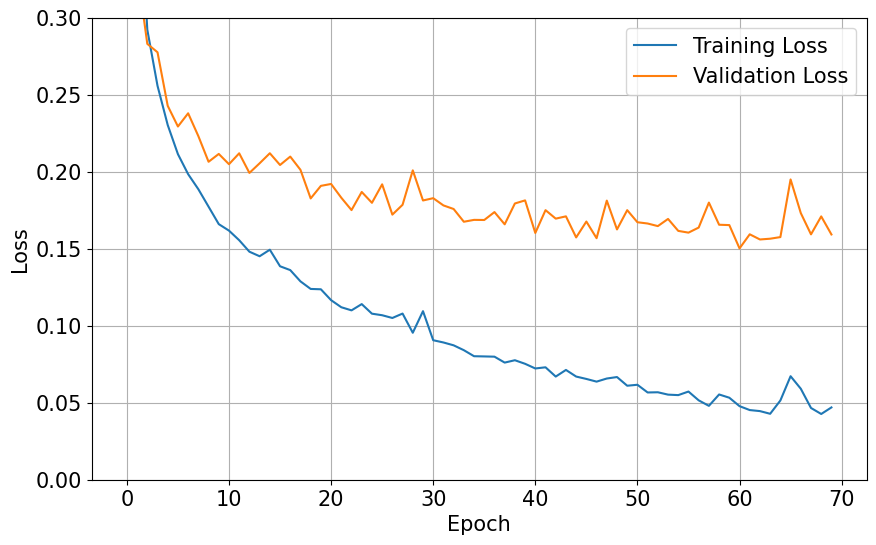

In [8]:
# optimizer = torch.optim.AdamW(model_fine_tune.parameters(), lr=0.00055, weight_decay=0.0, amsgrad=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.0, amsgrad=True)
train(model, optimizer, loss_function, num_epochs=70, train_loader=train_loader_fine_tune, val_loader=val_loader_fine_tune, ylim=[0, 0.3], save_model=False)

In [9]:
torch.save(model.state_dict(), r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project_compact\models\extrapolation_based\DimeNet_NREL_homo_extrapol_filter_1-2.4_v_1.pt')

In [8]:
prediction_fine_tune = predict_1d_target(model, data_loaders=[train_loader_fine_tune, val_loader_fine_tune, test_loader_fine_tune])

y_train_pred_fine_tune, y_train_true_fine_tune = prediction_fine_tune[0]

y_test_pred_fine_tune, y_test_true_fine_tune = prediction_fine_tune[1]

In [9]:
y_train_pred_t_fine_tune = transform_function.inverse_transform(y_train_pred_fine_tune.reshape(-1, 1)).flatten()
y_train_true_t_fine_tune = transform_function.inverse_transform(y_train_true_fine_tune.reshape(-1, 1)).flatten()

y_test_pred_t_fine_tune = transform_function.inverse_transform(y_test_pred_fine_tune.reshape(-1, 1)).flatten()
y_test_true_t_fine_tune = transform_function.inverse_transform(y_test_true_fine_tune.reshape(-1, 1)).flatten()

In [14]:
import numpy as np

train_cat = np.concatenate((y_train_pred_t_fine_tune.reshape(-1,1), y_train_true_t_fine_tune.reshape(-1,1)), axis=1)

np.savetxt('homo_train_pred_true.csv', train_cat, delimiter=',')

test_cat = np.concatenate((y_test_pred_t_fine_tune.reshape(-1,1), y_test_true_t_fine_tune.reshape(-1,1)), axis=1)

np.savetxt('homo_test_pred_true.csv', test_cat, delimiter=',')

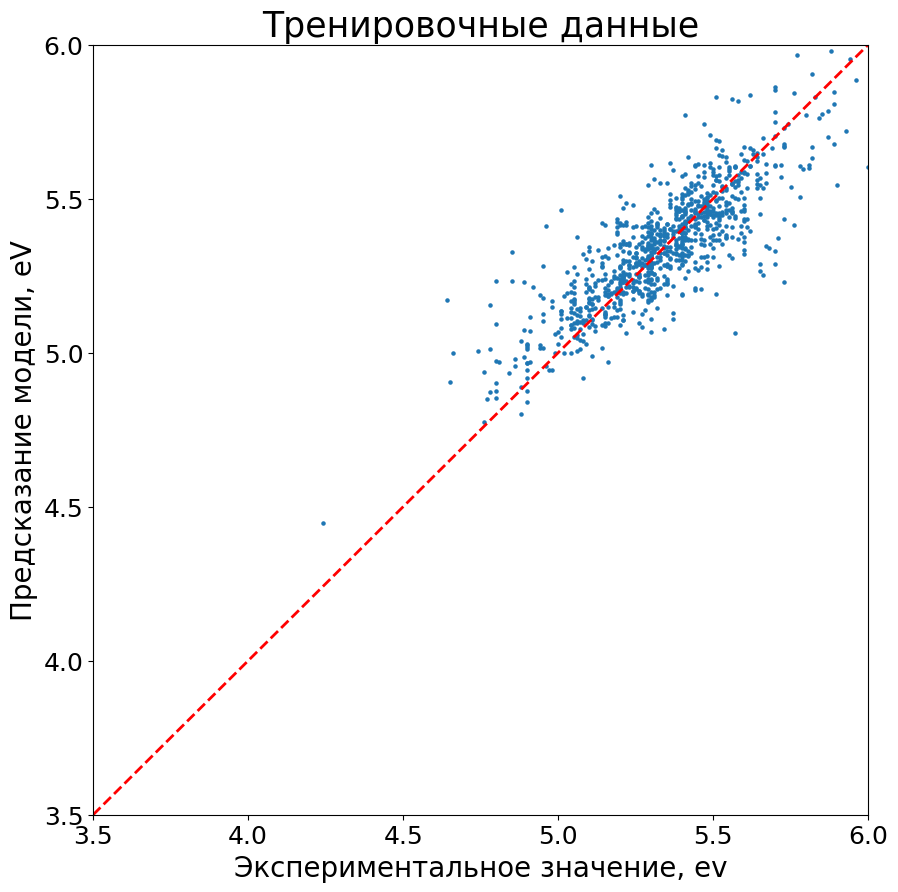

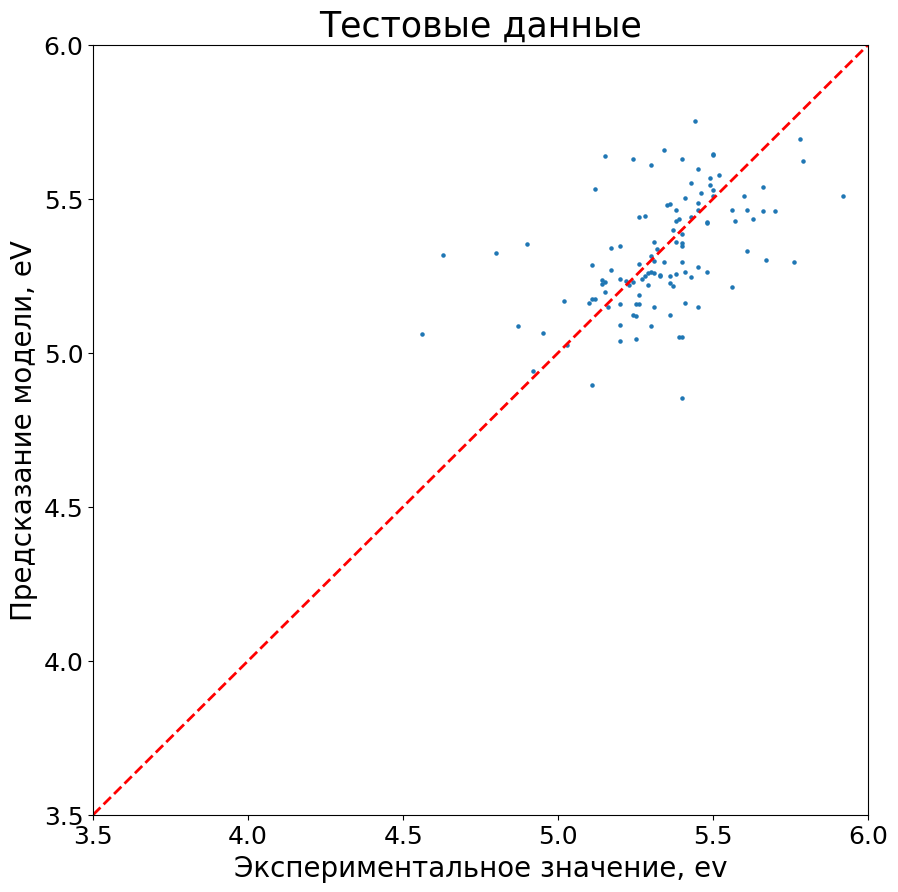

In [18]:
plot_scatter(y_train_true_t_fine_tune, y_train_pred_t_fine_tune,
             axis_lims=[3.5, 6, 3.5, 6],
             s=5,
             graph_title='Тренировочные данные',
             x_label='Экспериментальное значение, ev')

plot_scatter(y_test_true_t_fine_tune, y_test_pred_t_fine_tune,
             axis_lims=[3.5, 6, 3.5, 6],
             s=5,
             graph_title='Тестовые данные',
             x_label='Экспериментальное значение, ev')

In [11]:
mae_train_fine_tune = mean_absolute_error(y_train_true_t_fine_tune, y_train_pred_t_fine_tune)
mae_test_fine_tune = mean_absolute_error(y_test_true_t_fine_tune, y_test_pred_t_fine_tune)

print(f'MAE Train: {mae_train_fine_tune:.4f}')
print(f'MAE Test: {mae_test_fine_tune:.4f}')

MAE Train: 0.0846
MAE Test: 0.1448
